In [4]:
pip install numpy pandas matplotlib seaborn

  Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached pillow-11.2.1-cp313-cp313-win_amd64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl (12.6 MB)
Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl (11.5 MB)
Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.w

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path_to_files = '../out/build/vs-debug/media/csv/'

#### Sequential dataframes ####
seq_path = path_to_files + 'seq_w_cyl/'
columns = ['checkpoint', 'frame', 'dt', 'tot_sphs', 'frustum_sphs', 'vis_sphs', 'tot_cyls', 'frustum_cyls', 'vis_cyls', 'top_mipmap_level']
seq_ft = pd.read_csv(seq_path + 'loaded_scene_8wql.cif_frame_times.csv', header=None, names=columns)
seq_ft['fps'] = 1.0 / seq_ft['dt']
seq_occ_ft = pd.read_csv(seq_path + 'occ_loaded_scene_8wql.cif_frame_times.csv', header=None, names=columns)
seq_occ_ft['fps'] = 1.0 / seq_occ_ft['dt']

seq_ft.describe()

,checkpoint,frame,dt,tot_sphs,frustum_sphs,vis_sphs,tot_cyls,frustum_cyls,vis_cyls,top_mipmap_level,fps
count,383.000000,383.000000,383.000000,383.0,383.000000,383.000000,383.0,383.000000,383.000000,383.0,383.000000
mean,69.093995,25.723238,0.896469,552008.0,99851.031332,99851.031332,519767.0,94864.101828,94864.101828,0.0,1.549232
std,70.697842,23.860012,0.553883,0.0,70833.020665,70833.020665,0.0,65740.720966,65740.720966,0.0,0.811838
min,2.000000,0.000000,0.298185,552008.0,32497.000000,32497.000000,519767.0,31679.000000,31679.000000,0.0,0.321903
25%,13.000000,8.000000,0.432434,552008.0,46058.000000,46058.000000,519767.0,45300.000000,45300.000000,0.0,0.844043
50%,47.000000,18.000000,0.794225,552008.0,72287.000000,72287.000000,519767.0,70494.000000,70494.000000,0.0,1.259089
75%,101.000000,35.500000,1.184775,552008.0,133224.000000,133224.000000,519767.0,118654.000000,118654.000000,0.0,2.312496
max,291.000000,99.000000,3.106530,552008.0,242338.000000,242338.000000,519767.0,230093.000000,230093.000000,0.0,3.353623


In [3]:
def mean_dts_between_tracks(df, name=''):
    """
    Calculate the mean dt in a track of checkpoints in a DataFrame.
    """
    df_checkpoint_2 = df[(df['checkpoint'] == 2)]
    df_checkpoint_40 = df[(df['checkpoint'] == 40)]
    df_checkpoint_291 = df[(df['checkpoint'] == 291)]

    df_checkpoint_2_mean = df_checkpoint_2.groupby(['tot_sphs', 'tot_cyls'])['fps'].mean().reset_index()
    df_checkpoint_40_mean = df_checkpoint_40.groupby(['tot_sphs', 'tot_cyls'])['fps'].mean().reset_index()
    df_checkpoint_291_mean = df_checkpoint_291.groupby(['tot_sphs', 'tot_cyls'])['fps'].mean().reset_index()

    print(f"{name} FPS mean (checkpoint 2):")
    print(df_checkpoint_2_mean)
    print(f"{name} FPS mean (checkpoint 40):")
    print(df_checkpoint_40_mean)
    print(f"{name} FPS mean (checkpoint 291):")
    print(df_checkpoint_291_mean)

mean_dts_between_tracks(seq_ft, 'Sequential version without occlusion culling')
print("\n")
mean_dts_between_tracks(seq_occ_ft, 'Sequential version with occlusion culling')

Sequential version without occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls       fps
0    552008    519767  2.129886
Sequential version without occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls       fps
0    552008    519767  1.241075
Sequential version without occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls       fps
0    552008    519767  0.865163


Sequential version with occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls       fps
0    552008    519767  1.737579
Sequential version with occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls       fps
0    552008    519767  0.773399
Sequential version with occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls       fps
0    552008    519767  0.390083


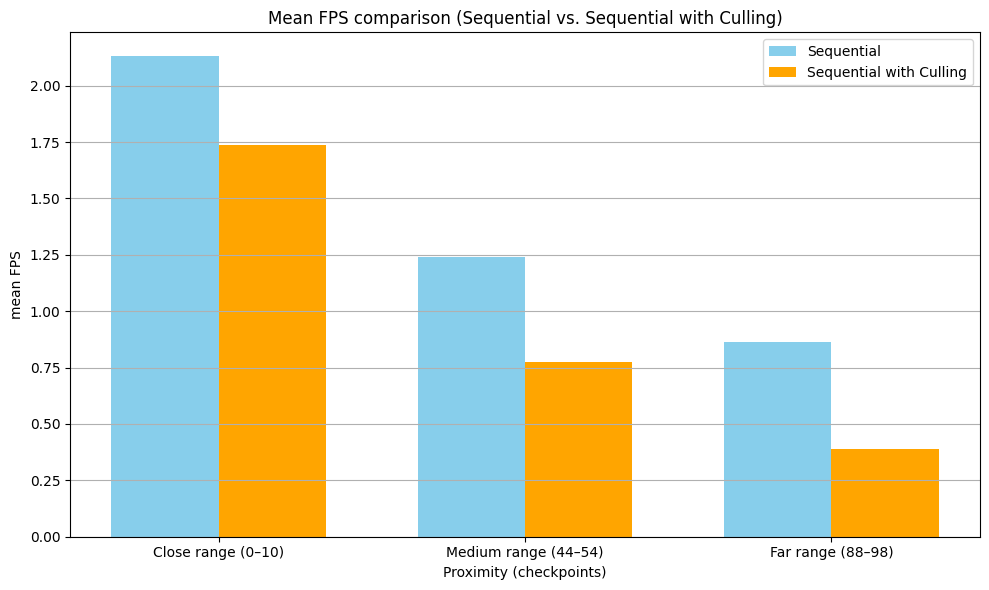

In [11]:
# Función para extraer promedio de FPS por rango de checkpoint
def mean_fps_in_range(df, checkpoint):
    subset = df[(df['checkpoint'] == checkpoint)]
    return subset['fps'].mean()

# Rangos a evaluar
checkpoints = [2, 40, 291]
labels = ['Close range (0–10)', 'Medium range (44–54)', 'Far range (88–98)']

# Calcular promedios para cada rango
seq_means = [mean_fps_in_range(seq_ft, checkpoint) for checkpoint in checkpoints]
seq_occ_means = [mean_fps_in_range(seq_occ_ft, checkpoint) for checkpoint in checkpoints]

# Crear gráfico de barras
x = range(len(checkpoints))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], seq_means, width=width, label='Sequential', color='skyblue')
plt.bar([i + width/2 for i in x], seq_occ_means, width=width, label='Sequential with Culling', color='orange')

plt.xlabel('Proximity (checkpoints)')
plt.ylabel('mean FPS')
plt.title('Mean FPS comparison (Sequential vs. Sequential with Culling)')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [3]:
#### Fst parallel dataframes ####
fst_parallel_path = path_to_files + 'fst_parallel_w_cyl/'
columns = ['checkpoint', 'frame', 'dt', 'tot_sphs', 'frustum_sphs', 'vis_sphs', 'tot_cyls', 'frustum_cyls', 'vis_cyls', 'top_mipmap_level']

## CPU frustum culling without occlusion culling
fst_parallel_cpu_ft = pd.read_csv(fst_parallel_path + 'loaded_scene_8wql.cif_cpu_frame_times.csv', header=None, names=columns)
fst_parallel_cpu_ft['fps'] = 1.0 / fst_parallel_cpu_ft['dt']

## CPU frustum culling with occlusion culling
fst_parallel_cpu_occ_ft = pd.read_csv(fst_parallel_path + 'occ_loaded_scene_8wql.cif_cpu_frame_times.csv', header=None, names=columns)
fst_parallel_cpu_occ_ft['fps'] = 1.0 / fst_parallel_cpu_occ_ft['dt']

## GPU frustum culling without occlusion culling
fst_parallel_gpu_ft = pd.read_csv(fst_parallel_path + 'loaded_scene_8wql.cif_gpu_frame_times.csv', header=None, names=columns)
fst_parallel_gpu_ft['fps'] = 1.0 / fst_parallel_gpu_ft['dt']

## GPU frustum culling with occlusion culling
fst_parallel_gpu_occ_ft = pd.read_csv(fst_parallel_path + 'occ_loaded_scene_8wql.cif_gpu_frame_times.csv', header=None, names=columns)
fst_parallel_gpu_occ_ft['fps'] = 1.0 / fst_parallel_gpu_occ_ft['dt']

fst_parallel_cpu_ft.describe()

,checkpoint,frame,dt,tot_sphs,frustum_sphs,vis_sphs,tot_cyls,frustum_cyls,vis_cyls,top_mipmap_level,fps
count,9806.000000,9806.000000,9806.000000,9806.0,9806.000000,9806.000000,9806.0,9806.000000,9806.000000,9806.0,9806.000000
mean,67.032225,543.347338,0.033698,552008.0,286000.470222,286000.470222,519767.0,270442.699164,270442.699164,0.0,37.214622
std,78.206442,375.449896,0.027897,0.0,168511.988245,168511.988245,0.0,157877.752993,157877.752993,0.0,12.798880
min,2.000000,0.000000,0.015427,552008.0,35602.000000,35602.000000,519767.0,35270.000000,35270.000000,0.0,3.895097
25%,24.000000,222.000000,0.020298,552008.0,133630.000000,133630.000000,519767.0,126361.000000,126361.000000,0.0,25.740175
50%,40.000000,494.000000,0.028034,552008.0,255998.000000,255998.000000,519767.0,242157.000000,242157.000000,0.0,35.671418
75%,73.000000,796.000000,0.038850,552008.0,454318.000000,454318.000000,519767.0,428833.000000,428833.000000,0.0,49.265634
max,291.000000,1537.000000,0.256733,552008.0,551271.000000,551271.000000,519767.0,519046.000000,519046.000000,0.0,64.820577


In [8]:
mean_dts_between_tracks(fst_parallel_cpu_ft, 'First parallel version with CPU frustum culling and without occlusion culling')

First parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls        fps
0    552008    519767  21.386596
First parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls        fps
0    552008    519767  48.502876
First parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls        fps
0    552008    519767  32.896328


In [9]:
mean_dts_between_tracks(fst_parallel_cpu_occ_ft, 'First parallel version with CPU frustum culling and occlusion culling')

First parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls        fps
0    552008    519767  17.834809
First parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls        fps
0    552008    519767  43.459275
First parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls        fps
0    552008    519767  30.702579


In [10]:
mean_dts_between_tracks(fst_parallel_gpu_ft, 'First parallel version with GPU frustum culling and without occlusion culling')

First parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls       fps
0    552008    519767  7.327143
First parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls        fps
0    552008    519767  144.54207
First parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls        fps
0    552008    519767  144.69986


In [11]:
mean_dts_between_tracks(fst_parallel_gpu_occ_ft, 'First parallel version with GPU frustum culling and occlusion culling')

First parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls        fps
0    552008    519767  23.207924
First parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls        fps
0    552008    519767  144.10169
First parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls         fps
0    552008    519767  144.381728


In [12]:
def vis_entities_pcnt(df, reduced_col_sph = 'vis_sphs', col_name_sph = 'occluded spheres %', reduced_col_cyl = 'vis_cyls', col_name_cyl = 'occluded cylinders %'):
    df = df.copy()
    df[col_name_sph] = df.apply(
        lambda row: ((row['tot_sphs'] - row[reduced_col_sph]) / row['tot_sphs'])*100.0 if row['tot_sphs'] > 0 else 0.0, axis=1)
    df[col_name_cyl] = df.apply(
        lambda row: ((row['tot_cyls'] - row[reduced_col_cyl]) / row['tot_cyls'])*100.0 if row['tot_cyls'] > 0 else 0.0, axis=1)
    grouped = df.groupby('checkpoint')[[col_name_sph, col_name_cyl]].mean().reset_index()

    print(grouped)

In [13]:
vis_entities_pcnt(fst_parallel_cpu_occ_ft)

    checkpoint  occluded spheres %  occluded cylinders %
0            1           98.103706             97.656863
1            2           97.981594             97.555199
2           13           96.023661             95.799011
3           24           83.772320             82.699923
4           36           68.565537             65.762584
5           40           85.304105             83.546824
6           47           53.840677             50.813277
7           60           32.059986             27.537852
8           73           27.869705             20.857975
9           91           13.662568              3.923535
10         101           97.579534             96.998783
11         291           19.537730              1.688336


In [14]:
vis_entities_pcnt(fst_parallel_gpu_occ_ft)

    checkpoint  occluded spheres %  occluded cylinders %
0            2           97.960864             97.543234
1           13           95.973129             95.785865
2           24           83.819366             82.731188
3           36           69.029117             65.882735
4           40           73.192472             69.384050
5           47           53.922301             50.838635
6           60           32.039092             27.538902
7           73           27.802624             20.861630
8           91           13.676595              3.923825
9          101           97.533177             96.973909
10         291           19.516288              1.688292


In [15]:
vis_entities_pcnt(fst_parallel_cpu_occ_ft, 'frustum_sphs', 'frustum culled sphs %', 'frustum_cyls', 'frustum culled cyls %')

    checkpoint  frustum culled sphs %  frustum culled cyls %
0            1              96.215453              96.065545
1            2              93.550456              93.214267
2           13              85.942776              85.661460
3           24              75.792018              75.688914
4           36              53.624223              53.410470
5           40              78.356259              77.873957
6           47              39.965182              39.780325
7           60              17.697207              17.495147
8           73              15.547420              15.773221
9           91               2.746156               2.781054
10         101              91.656280              91.284556
11         291               0.133513               0.138716


In [16]:
vis_entities_pcnt(fst_parallel_gpu_occ_ft, 'frustum_sphs', 'frustum culled sphs %', 'frustum_cyls', 'frustum culled cyls %')

    checkpoint  frustum culled sphs %  frustum culled cyls %
0            2              93.550456              93.214267
1           13              85.942776              85.661460
2           24              75.792018              75.688914
3           36              53.624223              53.410470
4           40              58.752047              58.177029
5           47              39.965182              39.780325
6           60              17.697207              17.495147
7           73              15.547420              15.773221
8           91               2.746156               2.781054
9          101              91.656280              91.284556
10         291               0.133513               0.138716


In [18]:
def perf_comparison(df1, df2, name1='CPU', name2='GPU'):
    """
    Compare the performance of two DataFrames.
    """
    df1_mean = df1.groupby('checkpoint')['fps'].mean().reset_index(name='fps_' + name1)
    df2_mean = df2.groupby('checkpoint')['fps'].mean().reset_index(name='fps_' + name2)

    compare_cpu_gpu = pd.merge(df1_mean, df2_mean, on='checkpoint')

    plt.figure(figsize=(12, 6))
    plt.plot(compare_cpu_gpu['checkpoint'], compare_cpu_gpu['fps_' + name1], label=name1, marker='o')
    plt.plot(compare_cpu_gpu['checkpoint'], compare_cpu_gpu['fps_' + name2], label=name2, marker='s')
    plt.title(f"FPS por checkpoint ({name1} vs {name2})")
    plt.xlabel("Checkpoint")
    plt.ylabel("FPS")
    plt.legend()
    plt.grid(True)
    plt.show()



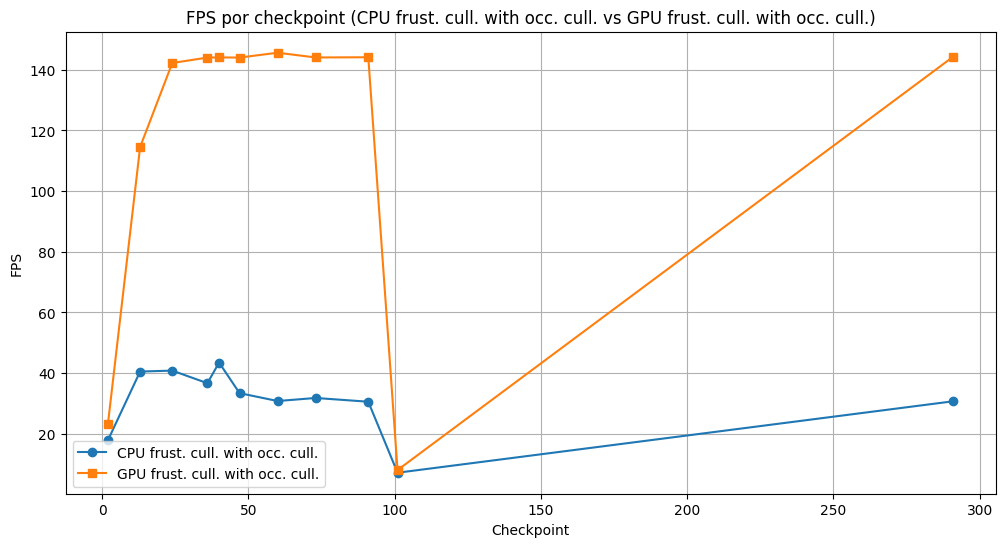

In [19]:
perf_comparison(fst_parallel_cpu_occ_ft, fst_parallel_gpu_occ_ft, 'CPU frust. cull. with occ. cull.', 'GPU frust. cull. with occ. cull.')

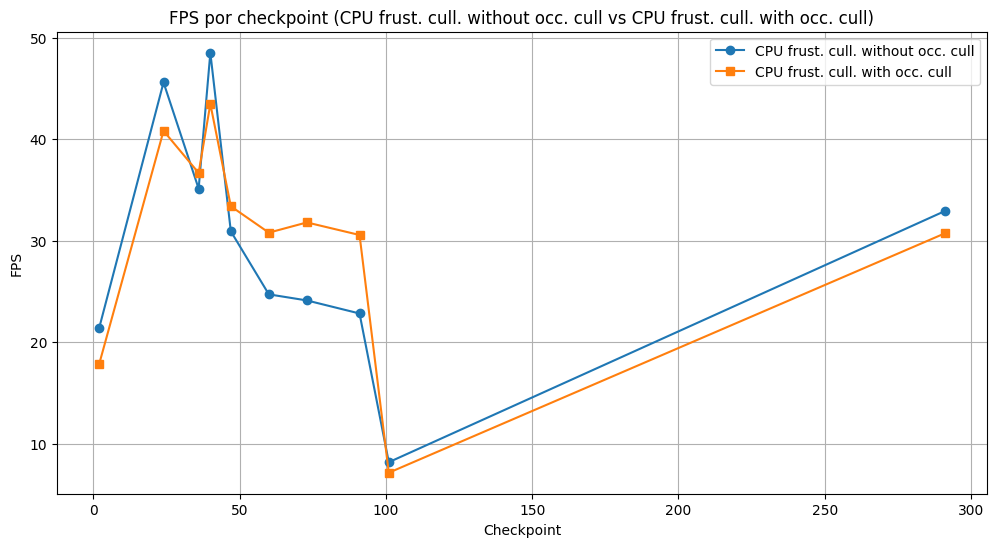

In [20]:
perf_comparison(fst_parallel_cpu_ft, fst_parallel_cpu_occ_ft, 'CPU frust. cull. without occ. cull', 'CPU frust. cull. with occ. cull')

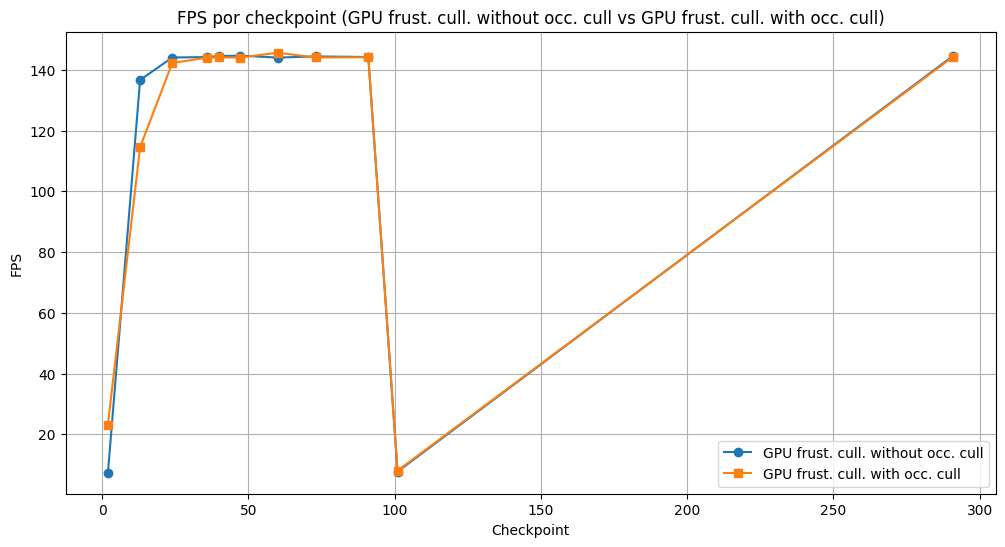

In [21]:
perf_comparison(fst_parallel_gpu_ft, fst_parallel_gpu_occ_ft, 'GPU frust. cull. without occ. cull', 'GPU frust. cull. with occ. cull')

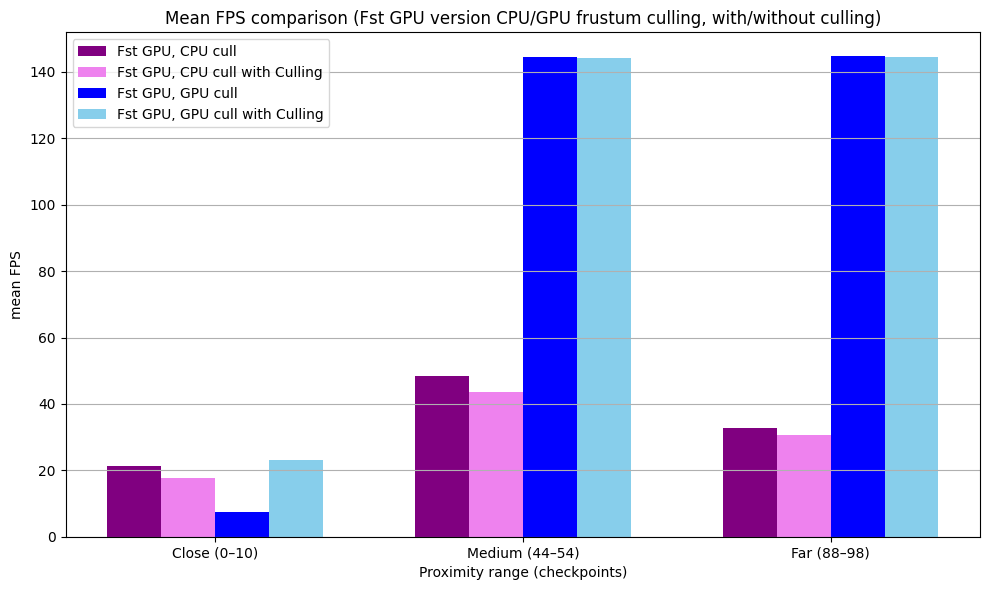

In [8]:
# Función para extraer promedio de FPS por rango de checkpoint
def mean_fps_in_range(df, checkpoint):
    subset = df[(df['checkpoint'] == checkpoint)]
    return subset['fps'].mean()

# Rangos a evaluar
checkpoints = [2, 40, 291]
labels = ['Close (0–10)', 'Medium (44–54)', 'Far (88–98)']

# Calcular promedios para cada rango
fst_parallel_cpu_ft_means = [mean_fps_in_range(fst_parallel_cpu_ft, checkpoint) for checkpoint in checkpoints]
fst_parallel_cpu_occ_ft_means = [mean_fps_in_range(fst_parallel_cpu_occ_ft, checkpoint) for checkpoint in checkpoints]
fst_parallel_gpu_ft_means = [mean_fps_in_range(fst_parallel_gpu_ft, checkpoint) for checkpoint in checkpoints]
fst_parallel_gpu_occ_ft_means = [mean_fps_in_range(fst_parallel_gpu_occ_ft, checkpoint) for checkpoint in checkpoints]

# Crear gráfico de barras
x = range(len(checkpoints))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - 3*width/4 for i in x], fst_parallel_cpu_ft_means, width=width/2.0, label='Fst GPU, CPU cull', color='purple')
plt.bar([i - width/4 for i in x], fst_parallel_cpu_occ_ft_means, width=width/2.0, label='Fst GPU, CPU cull with Culling', color='violet')
plt.bar([i + width/4 for i in x], fst_parallel_gpu_ft_means, width=width/2.0, label='Fst GPU, GPU cull', color='blue')
plt.bar([i + 3*width/4 for i in x], fst_parallel_gpu_occ_ft_means, width=width/2.0, label='Fst GPU, GPU cull with Culling', color='skyblue')

plt.xlabel('Proximity range (checkpoints)')
plt.ylabel('mean FPS')
plt.title('Mean FPS comparison (Fst GPU version CPU/GPU frustum culling, with/without culling)')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [4]:
#### Scnd parallel dataframes ####
scnd_parallel_path = path_to_files + 'scnd_parallel_w_cyl/'
columns = ['checkpoint', 'frame', 'dt', 'tot_sphs', 'frustum_sphs', 'vis_sphs', 'tot_cyls', 'frustum_cyls', 'vis_cyls', 'top_mipmap_level']

## CPU frustum culling without occlusion culling
scnd_parallel_cpu_ft = pd.read_csv(scnd_parallel_path + 'loaded_scene_8wql.cif_cpu_frame_times.csv', header=None, names=columns)
scnd_parallel_cpu_ft['fps'] = 1.0 / scnd_parallel_cpu_ft['dt']

## CPU frustum culling with occlusion culling
scnd_parallel_cpu_occ_ft = pd.read_csv(scnd_parallel_path + 'occ_loaded_scene_8wql.cif_cpu_frame_times.csv', header=None, names=columns)
scnd_parallel_cpu_occ_ft['fps'] = 1.0 / scnd_parallel_cpu_occ_ft['dt']

## GPU frustum culling without occlusion culling
scnd_parallel_gpu_ft = pd.read_csv(scnd_parallel_path + 'loaded_scene_8wql.cif_gpu_frame_times.csv', header=None, names=columns)
scnd_parallel_gpu_ft['fps'] = 1.0 / scnd_parallel_gpu_ft['dt']

## GPU frustum culling with occlusion culling
scnd_parallel_gpu_occ_ft = pd.read_csv(scnd_parallel_path + 'occ_loaded_scene_8wql.cif_gpu_frame_times.csv', header=None, names=columns)
scnd_parallel_gpu_occ_ft['fps'] = 1.0 / scnd_parallel_gpu_occ_ft['dt']

scnd_parallel_cpu_ft.describe()

,checkpoint,frame,dt,tot_sphs,frustum_sphs,vis_sphs,tot_cyls,frustum_cyls,vis_cyls,top_mipmap_level,fps
count,85.000000,85.000000,85.000000,85.0,85.000000,85.000000,85.0,85.000000,85.000000,85.0,85.000000
mean,62.294118,15.741176,1.079240,552008.0,47513.152941,47513.152941,519767.0,45371.270588,45371.270588,4.0,1.064737
std,99.328079,10.583177,0.547203,0.0,26643.715469,26643.715469,0.0,22335.832175,22335.832175,0.0,0.277059
min,2.000000,0.000000,0.786933,552008.0,35602.000000,35602.000000,519767.0,35270.000000,35270.000000,4.0,0.412140
25%,2.000000,7.000000,0.819482,552008.0,35602.000000,35602.000000,519767.0,35270.000000,35270.000000,4.0,1.118286
50%,40.000000,14.000000,0.858100,552008.0,36921.000000,36921.000000,519767.0,36610.000000,36610.000000,4.0,1.165365
75%,40.000000,25.000000,0.894226,552008.0,36921.000000,36921.000000,519767.0,36610.000000,36610.000000,4.0,1.220283
max,291.000000,35.000000,2.426360,552008.0,109830.000000,109830.000000,519767.0,97606.000000,97606.000000,4.0,1.270756


In [23]:
mean_dts_between_tracks(scnd_parallel_cpu_ft, 'Second parallel version with CPU frustum culling and without occlusion culling')

Second parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls       fps
0    552008    519767  1.188127
Second parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls       fps
0    552008    519767  1.172628
Second parallel version with CPU frustum culling and without occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls       fps
0    552008    519767  0.424264


In [24]:
mean_dts_between_tracks(scnd_parallel_cpu_occ_ft, 'Second parallel version with CPU frustum culling and occlusion culling')

Second parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls       fps
0    552008    519767  3.334763
Second parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls       fps
0    552008    519767  1.147589
Second parallel version with CPU frustum culling and occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls       fps
0    552008    519767  0.831549


In [25]:
mean_dts_between_tracks(scnd_parallel_gpu_ft, 'Second parallel version with GPU frustum culling and without occlusion culling')

Second parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls       fps
0    552008    519767  1.136173
Second parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls       fps
0    552008    519767  0.522373
Second parallel version with GPU frustum culling and without occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls       fps
0    552008    519767  0.414342


In [26]:
mean_dts_between_tracks(scnd_parallel_gpu_occ_ft, 'Second parallel version with GPU frustum culling and occlusion culling')

Second parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 2):
   tot_sphs  tot_cyls       fps
0    552008    519767  3.531838
Second parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 40):
   tot_sphs  tot_cyls       fps
0    552008    519767  0.956729
Second parallel version with GPU frustum culling and occlusion culling FPS mean (checkpoint 291):
   tot_sphs  tot_cyls       fps
0    552008    519767  0.478281


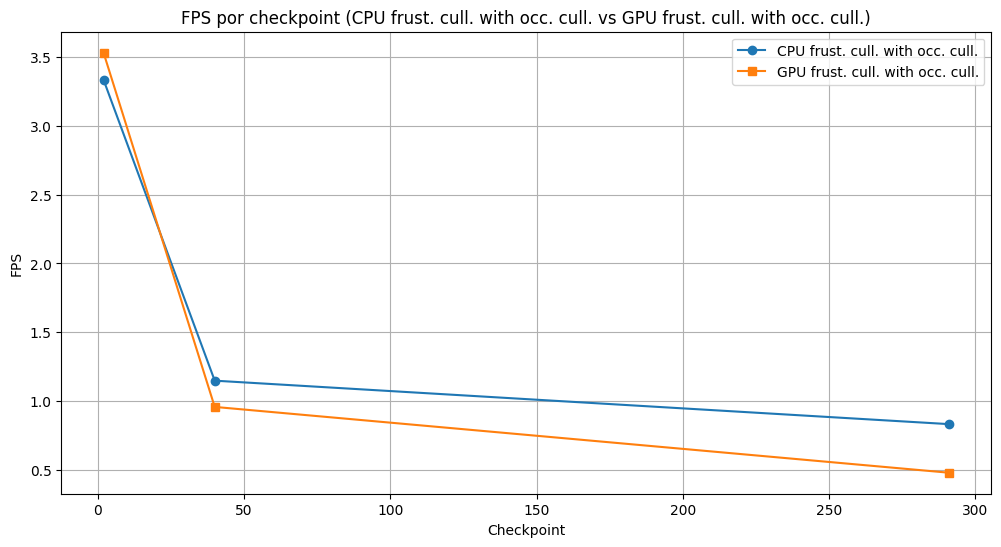

In [27]:
perf_comparison(scnd_parallel_cpu_occ_ft, scnd_parallel_gpu_occ_ft, 'CPU frust. cull. with occ. cull.', 'GPU frust. cull. with occ. cull.')

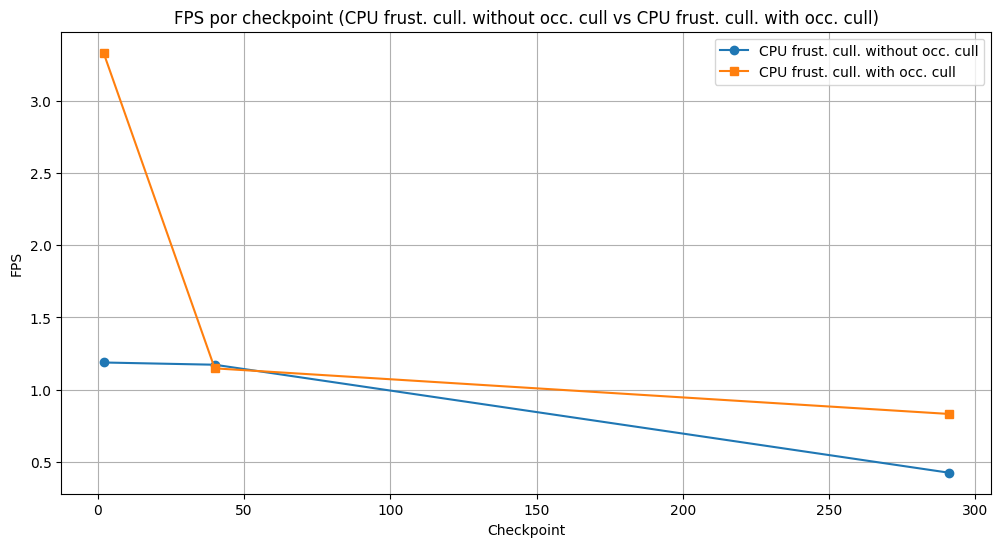

In [29]:
perf_comparison(scnd_parallel_cpu_ft, scnd_parallel_cpu_occ_ft, 'CPU frust. cull. without occ. cull', 'CPU frust. cull. with occ. cull')

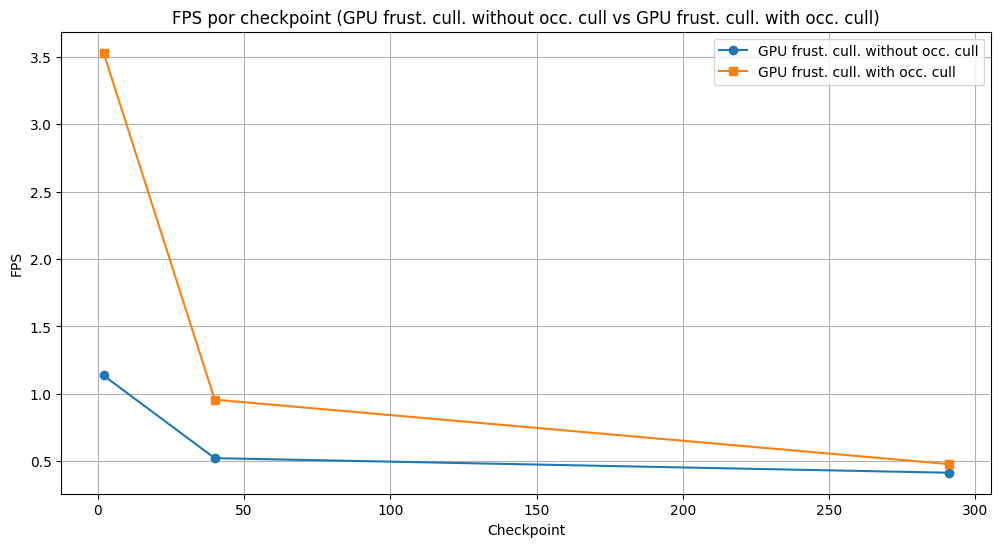

In [30]:
perf_comparison(scnd_parallel_gpu_ft, scnd_parallel_gpu_occ_ft, 'GPU frust. cull. without occ. cull', 'GPU frust. cull. with occ. cull')

In [5]:
def perf_comparison_global(df1, df2, df3, name1='Sequential', name2='Fst. GPU', name3='Scnd. GPU'):
    """
    Compare the performance of two DataFrames.
    """
    df1_mean = df1.groupby('checkpoint')['fps'].mean().reset_index(name='fps_' + name1)
    df2_mean = df2.groupby('checkpoint')['fps'].mean().reset_index(name='fps_' + name2)
    df3_mean = df3.groupby('checkpoint')['fps'].mean().reset_index(name='fps_' + name3)

    compare_cpu_gpu = pd.merge(df1_mean, df2_mean, on='checkpoint')
    compare_cpu_gpu = pd.merge(compare_cpu_gpu, df3_mean, on='checkpoint')

    # Parámetros para barras agrupadas
    x = np.arange(len(compare_cpu_gpu['checkpoint']))
    bar_width = 0.25

    # Crear gráfico
    plt.figure(figsize=(14, 6))
    plt.bar(x - bar_width, compare_cpu_gpu['fps_' + name1], width=bar_width, label=name1)
    plt.bar(x, compare_cpu_gpu['fps_' + name2], width=bar_width, label=name2)
    plt.bar(x + bar_width, compare_cpu_gpu['fps_' + name3], width=bar_width, label=name3)

    plt.xticks(x, compare_cpu_gpu['checkpoint'], rotation=45)
    plt.xlabel("Checkpoint")
    plt.ylabel("FPS Promedio")
    plt.title(f"Comparación de FPS por Checkpoint\n({name1} vs {name2} vs {name3})")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

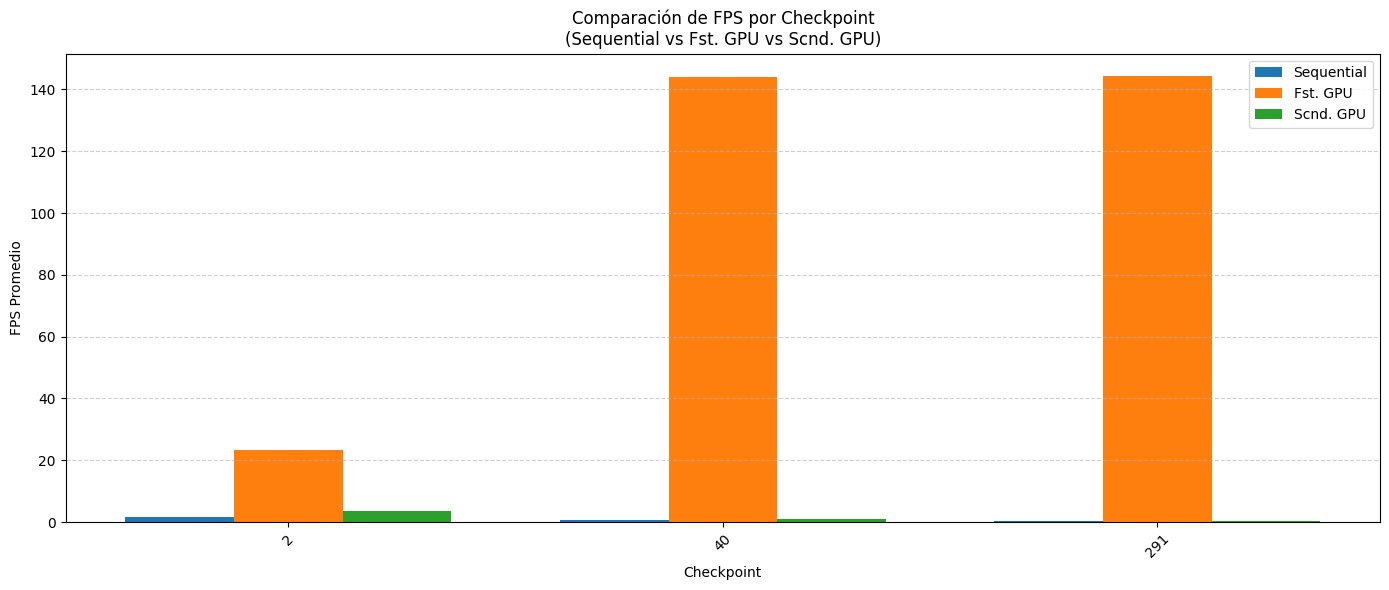

In [6]:
perf_comparison_global(seq_occ_ft, fst_parallel_gpu_occ_ft, scnd_parallel_gpu_occ_ft, 'Sequential', 'Fst. GPU', 'Scnd. GPU')

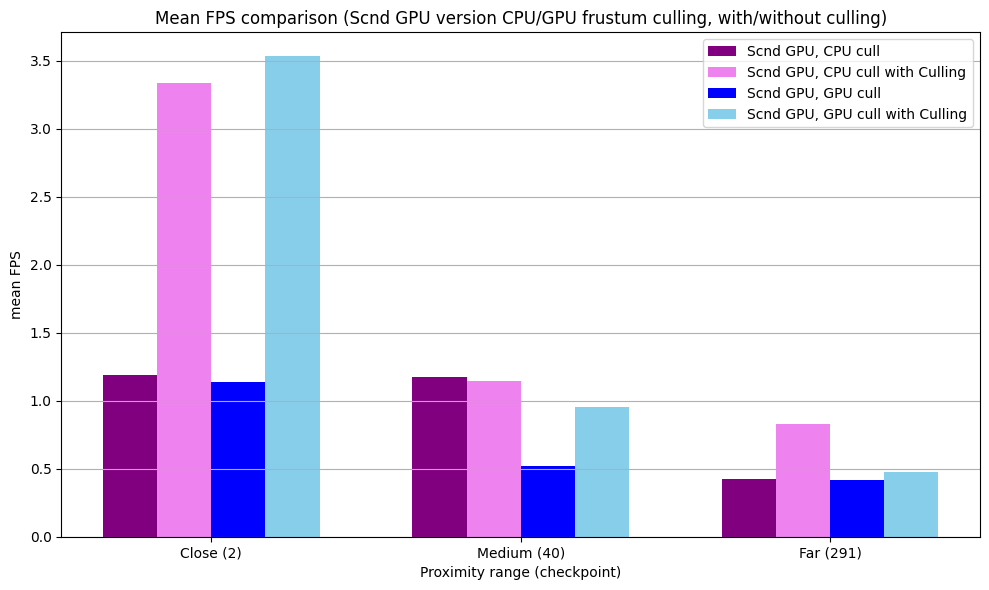

In [16]:
# Función para extraer promedio de FPS por rango de checkpoint
def mean_fps_in_range(df, checkpoint):
    subset = df[(df['checkpoint'] == checkpoint)]
    return subset['fps'].mean()

# Rangos a evaluar
checkpoints = [2, 40, 291]
labels = ['Close (2)', 'Medium (40)', 'Far (291)']

# Calcular promedios para cada rango
scnd_parallel_cpu_ft_means = [mean_fps_in_range(scnd_parallel_cpu_ft, checkpoint) for checkpoint in checkpoints]
scnd_parallel_cpu_occ_ft_means = [mean_fps_in_range(scnd_parallel_cpu_occ_ft, checkpoint) for checkpoint in checkpoints]
scnd_parallel_gpu_ft_means = [mean_fps_in_range(scnd_parallel_gpu_ft, checkpoint) for checkpoint in checkpoints]
scnd_parallel_gpu_occ_ft_means = [mean_fps_in_range(scnd_parallel_gpu_occ_ft, checkpoint) for checkpoint in checkpoints]

# Crear gráfico de barras
x = range(len(checkpoints))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - 3*width/4 for i in x], scnd_parallel_cpu_ft_means, width=width/2.0, label='Scnd GPU, CPU cull', color='purple')
plt.bar([i - width/4 for i in x], scnd_parallel_cpu_occ_ft_means, width=width/2.0, label='Scnd GPU, CPU cull with Culling', color='violet')
plt.bar([i + width/4 for i in x], scnd_parallel_gpu_ft_means, width=width/2.0, label='Scnd GPU, GPU cull', color='blue')
plt.bar([i + 3*width/4 for i in x], scnd_parallel_gpu_occ_ft_means, width=width/2.0, label='Scnd GPU, GPU cull with Culling', color='skyblue')

plt.xlabel('Proximity range (checkpoint)')
plt.ylabel('mean FPS')
plt.title('Mean FPS comparison (Scnd GPU version CPU/GPU frustum culling, with/without culling)')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()